In [1]:
import pyclara
import xtrack
import matplotlib.pyplot as plt
import pybdsim
import numpy as np
import scipy.constants as constants

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


### Existing focus location

ip beta  :  0.2593548064535031 0.5133389531089778
ip sigma :  39.44779890844379 55.49805148519961
scr beta :  2.0387955732866896 1.864532985968465


(7.5, 12.5)

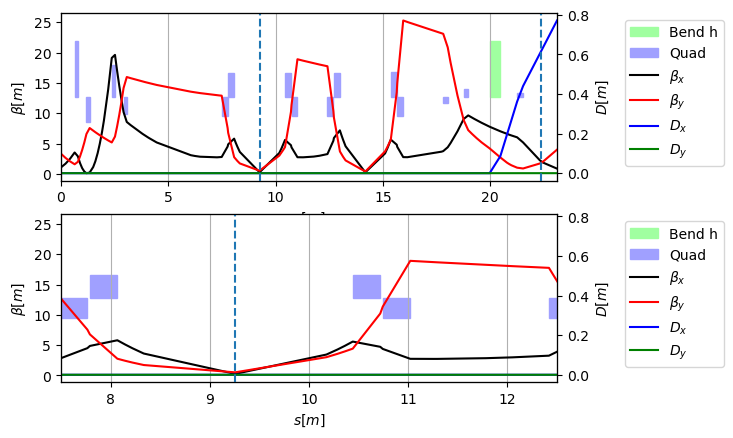

In [8]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
t0d = xsuite_twiss['dict_twiss0']
p = xsuite_twiss['xtrack_particles']

# s location of IP
ip_idx = (t['name'] == "CLA_FEC1_SIM_FOCUS_01")
scr_idx = (t['name'] == "CLA_FED_DIA_SCR_02")

ip_s = t['s'][ip_idx][0]
scr_s = t['s'][scr_idx][0]

ip_betx = t['betx'][ip_idx][0]
ip_bety = t['bety'][ip_idx][0]
scr_betx = t['betx'][scr_idx][0]
scr_bety = t['bety'][scr_idx][0]


print("ip beta  : ", ip_betx, ip_bety)
print("ip sigma : ", np.sqrt(3e-6/500*ip_betx)/1e-6, np.sqrt(3e-6/500*ip_bety)/1e-6)
print("scr beta : ",scr_betx, scr_bety)


ax = plt.subplot(2,1,1)
t.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(scr_s,ls="--")

# plt.xlim(7.5,12.5)

ax = plt.subplot(2,1,2)
t.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(scr_s,ls="--")
plt.xlim(7.5,12.5)

### Optimise existing IP location using 6 upstream quads
* CLA_FEH_MAG_QUAD_01
* CLA_FEH_MAG_QUAD_02
* CLA_FEA_MAG_QUAD_16
* CLA_FEA_MAG_QUAD_15
* CLA_FEH_MAG_QUAD_01
* CLA_FEH_MAG_QUAD_02

CLA_FEH_MAG_QUAD_01 -6.269079422382671
CLA_FEH_MAG_QUAD_02 7.800671480144403
CLA_FEA_MAG_QUAD_16 -5.689593333333333
CLA_FEA_MAG_QUAD_15 10.319133333333335
CLA_FEA_MAG_QUAD_14 -8.422733333333333
CLA_FEA_MAG_QUAD_13 18.413533333333337
FEBE_DRIFT_177 0.9205
FEBE_DRIFT_178 0.9205
                                             
Optimize - start penalty: 0.555                             
Matching: model call n. 17319 penalty = 5.2172e-03              
Optimize - end penalty:  0.00521718                            
Table: 1352 rows, 21 cols
iteration                   penalty alpha tag tol_met target_active hit_limits vary_active ...
0                          0.555023    -1     nn      yy            nnnnnnn    yyyyyyy    
1                          0.555023    -1     nn      yy            nnnnnnn    yyyyyyy    
2                          0.511438     2     nn      yy            nnnnnnn    yyyyyyy    
3                          0.475433     2     nn      yy            nnnnnnn    yyyyyyy    
4 

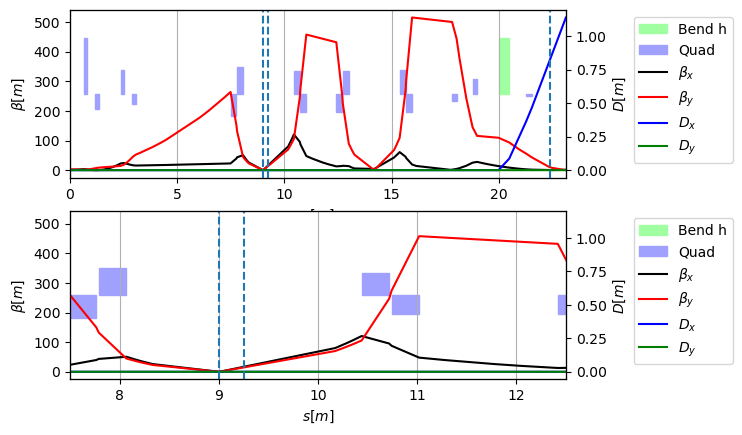

In [43]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")


e = xsuite_twiss['env']
l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
t0d = xsuite_twiss['dict_twiss0']
p = xsuite_twiss['xtrack_particles']

# indices of ip and screen 
ip_idx = (t['name'] == "CLA_FEC1_SIM_FOCUS_01")
scr_idx = (t['name'] == "CLA_FED_DIA_SCR_02")

# s location of IP
ip_s_orig = t['s'][ip_idx][0]
scr_s = t['s'][scr_idx][0]

fec1_length = l.get('FEBE_DRIFT_177.L') + l.get('FEBE_DRIFT_178.L')
e['fec1_length'] = fec1_length
e['fec1_focus_offset'] = 0.0
e['FEBE_DRIFT_177.L'] = 'fec1_length/2-fec1_focus_offset'
e['FEBE_DRIFT_178.L'] = 'fec1_length/2+fec1_focus_offset'

print('CLA_FEH_MAG_QUAD_01',l.get('CLA_FEH_MAG_QUAD_01.K1'))
print('CLA_FEH_MAG_QUAD_02',l.get('CLA_FEH_MAG_QUAD_02.K1'))
print('CLA_FEA_MAG_QUAD_16',l.get('CLA_FEA_MAG_QUAD_16.K1'))
print('CLA_FEA_MAG_QUAD_15',l.get('CLA_FEA_MAG_QUAD_15.K1'))
print('CLA_FEA_MAG_QUAD_14',l.get('CLA_FEA_MAG_QUAD_14.K1'))
print('CLA_FEA_MAG_QUAD_13',l.get('CLA_FEA_MAG_QUAD_13.K1'))
print('FEBE_DRIFT_177',l.get('FEBE_DRIFT_177.L'))
print('FEBE_DRIFT_178',l.get('FEBE_DRIFT_178.L'))

try : 
    opt = l.match(
        start='CLA_FEA_SIM_DIP_04_END', end='CLA_FED_SIM_DUMP_01_START',
        init=t0,
        vary=xtrack.VaryList(['fec1_focus_offset',
                              'CLA_FEH_MAG_QUAD_01.K1',
                              'CLA_FEH_MAG_QUAD_02.K1', 
                              'CLA_FEA_MAG_QUAD_16.K1',
                              'CLA_FEA_MAG_QUAD_15.K1',
                              'CLA_FEA_MAG_QUAD_14.K1',
                              'CLA_FEA_MAG_QUAD_13.K1'],
                             step=0.0001, limits=[-100, 100]),
        targets = [xtrack.TargetSet(betx=0.015, tol=5e-3, at='CLA_FEC1_SIM_FOCUS_01'),
                   xtrack.TargetSet(bety=0.015, tol=5e-3, at='CLA_FEC1_SIM_FOCUS_01')],
        n_steps_max=3500)
    print(opt.log())
except RuntimeError :
    pass

print('CLA_FEH_MAG_QUAD_01',l.get('CLA_FEH_MAG_QUAD_01.K1'))
print('CLA_FEH_MAG_QUAD_02',l.get('CLA_FEH_MAG_QUAD_02.K1'))
print('CLA_FEA_MAG_QUAD_16',l.get('CLA_FEA_MAG_QUAD_16.K1'))
print('CLA_FEA_MAG_QUAD_15',l.get('CLA_FEA_MAG_QUAD_15.K1'))
print('CLA_FEA_MAG_QUAD_14',l.get('CLA_FEA_MAG_QUAD_14.K1'))
print('CLA_FEA_MAG_QUAD_13',l.get('CLA_FEA_MAG_QUAD_13.K1'))
print('FEBE_DRIFT_177',l.get('FEBE_DRIFT_177.L'))
print('FEBE_DRIFT_178',l.get('FEBE_DRIFT_178.L'))


print('CLA_FEA_MAG_QUAD_07',l.get('CLA_FEA_MAG_QUAD_07.K1'))
print('CLA_FEA_MAG_QUAD_08',l.get('CLA_FEA_MAG_QUAD_08.K1'))
print('CLA_FED_MAG_QUAD_01',l.get('CLA_FED_MAG_QUAD_01.K1'))
print('CLA_FED_MAG_QUAD_02',l.get('CLA_FED_MAG_QUAD_02.K1'))
print('CLA_FED_MAG_QUAD_03',l.get('CLA_FED_MAG_QUAD_03.K1'))

try : 
    opt = l.match(
        start='CLA_FEA_SIM_DIP_04_END', end='CLA_FED_SIM_DUMP_01_START',
        init=t0,
        vary=xtrack.VaryList(['CLA_FEA_MAG_QUAD_07.K1',
                              'CLA_FEA_MAG_QUAD_08.K1',
                              'CLA_FED_MAG_QUAD_01.K1',
                              'CLA_FED_MAG_QUAD_02.K1',
                              'CLA_FED_MAG_QUAD_03.K1'],
                             step=0.001, limits=[-100, 100]),
        targets = [xtrack.TargetSet(betx=0.015*36, tol=5e-2, at='CLA_FED_DIA_SCR_02'),
                   xtrack.TargetSet(alfx=0.0, tol=1e-2, at='CLA_FED_DIA_SCR_02'),
                   xtrack.Target('bety',xtrack.LessThan(10), at='CLA_FED_DIA_SCR_02')],
        n_steps_max=5000)
    print(opt.log())
except RuntimeError :
    pass
    
print('CLA_FEA_MAG_QUAD_07',l.get('CLA_FEA_MAG_QUAD_07.K1'))
print('CLA_FEA_MAG_QUAD_08',l.get('CLA_FEA_MAG_QUAD_08.K1'))
print('CLA_FED_MAG_QUAD_01',l.get('CLA_FED_MAG_QUAD_01.K1'))
print('CLA_FED_MAG_QUAD_02',l.get('CLA_FED_MAG_QUAD_02.K1'))
print('CLA_FED_MAG_QUAD_03',l.get('CLA_FED_MAG_QUAD_03.K1'))

t_emq = l.twiss(method="4d",init=t0)

# s location of IP
ip_s = t_emq['s'][ip_idx][0]

epsilon_n = 3e-6
gamma = 250/0.511
epsilon = epsilon_n/gamma

ax = plt.subplot(2,1,1)
t_emq.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(ip_s_orig,ls="--")
plt.axvline(scr_s,ls="--")

ax = plt.subplot(2,1,2)
t_emq.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(ip_s_orig,ls="--")
plt.xlim(7.5,12.5)

plt.savefig("./EMQ_Xsuite.jpg")


ip_betx = t_emq['betx'][ip_idx][0]
ip_bety = t_emq['bety'][ip_idx][0]
scr_betx = t_emq['betx'][scr_idx][0]
scr_bety = t_emq['bety'][scr_idx][0]

print("ip beta  : ", ip_betx, ip_bety)
print("ip sigma : ", np.sqrt(epsilon*ip_betx)/1e-6, np.sqrt(epsilon*ip_bety)/1e-6)
print("scr beta : ",scr_betx, scr_bety)
print("scr sigma : ", np.sqrt(epsilon*scr_betx)/1e-6, np.sqrt(epsilon*scr_bety)/1e-6)

### Insert PMQs symmetrically around focus

/Users/stewart.boogert/miniconda3/envs/phys-py312/lib/python3.12/site-packages/xtrack/line.py:2919: FutureWarning: Line.insert_element is deprecated. Use Line.insert instead.
  warn('Line.insert_element is deprecated. Use Line.insert instead.', FutureWarning)


Slicing line:   0%|          | 0/160 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/162 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/164 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/166 [00:00<?, ?it/s]

                                             
Optimize - start penalty: 4.355                             
Matching: model call n. 14442 penalty = 5.8897e-03              
Optimize - end penalty:  0.00588971                            
Table: 1208 rows, 20 cols
iteration                   penalty alpha tag tol_met target_active hit_limits vary_active ...
0                           4.35507    -1     nn      yy            nnnnnn     yyyyyy     
1                           4.35507    -1     nn      yy            nnnnnn     yyyyyy     
2                           1.30003     0     nn      yy            nnnnnn     yyyyyy     
3                          0.916844     0     nn      yy            nnnnnn     yyyyyy     
4                          0.680937     1     nn      yy            nnnnnn     yyyyyy     
5                          0.258794     0     nn      yy            nnnnnn     yyyyyy     
6                          0.254252     4     nn      yy            nnnnnn     yyyyyy     
7     

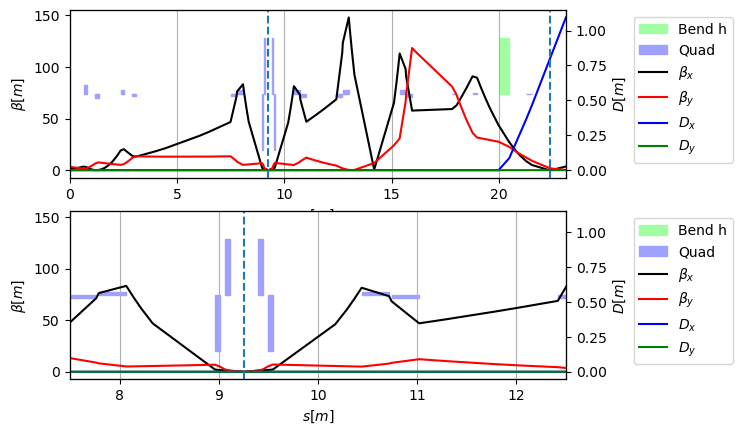

In [28]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

e = xsuite_twiss['env']
l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
t0d = xsuite_twiss['dict_twiss0']
p = xsuite_twiss['xtrack_particles']

# s location of IP and screen
ip_idx = (t['name'] == "CLA_FEC1_SIM_FOCUS_01")
scr_idx = (t['name'] == "CLA_FED_DIA_SCR_02")

ip_s = t['s'][ip_idx][0]
scr_s = t['s'][scr_idx][0]

hquadf = xtrack.Quadrupole(length=0.05,
                           k1=-119.400000)
hquadd = xtrack.Quadrupole(length=0.05,
                           k1=119.400000)

l.insert_element(element=hquadf,
                 name="HQUADF1",
                 at_s=ip_s-0.5-0.05-0.05)
l.insert_element(element=hquadd,
                 name="HQUADD1",
                 at_s=ip_s-0.5) 

l.insert_element(element=hquadd,
                 name="HQUADF2",
                 at_s=ip_s+0.5)
l.insert_element(element=hquadf,
                 name="HQUADD2",
                 at_s=ip_s+0.5+0.05+0.05)

# remove drift slices
pyclara.Converters.xsuite_Remove_DriftSlices(l)

# add variables for lengths 
fec1_length1 = l.get('FEBE_DRIFT_177..0.L') + l.get('FEBE_DRIFT_177..2..0.L') + \
               l.get('FEBE_DRIFT_177..2..2.L') + 2 * 0.05 # add quad lengths 

fec1_length2 = l.get('FEBE_DRIFT_178..0.L') + l.get('FEBE_DRIFT_178..2..0.L') + \
               l.get('FEBE_DRIFT_178..2..2.L') + 2 * 0.05 # add quad lengths

#print(fec1_length1, fec1_length2)

e['fec1_length'] = fec1_length1
e['fec1_pmq_doublet_offset'] = 0.45
e['fec1_pmq_doublet_spacing'] = 0.08

e['FEBE_DRIFT_177..0.L'] = 'fec1_length - 0.05 - fec1_pmq_doublet_spacing/2 - fec1_pmq_doublet_offset'
e['FEBE_DRIFT_177..2..0.L'] = 'fec1_pmq_doublet_spacing'
e['FEBE_DRIFT_177..2..2.L'] = 'fec1_pmq_doublet_offset - fec1_pmq_doublet_spacing/2 - 0.05'
e['FEBE_DRIFT_178..0.L'] = 'fec1_pmq_doublet_offset - fec1_pmq_doublet_spacing/2 - 0.05'
e['FEBE_DRIFT_178..2..0.L'] = 'fec1_pmq_doublet_spacing'
e['FEBE_DRIFT_178..2..2.L'] = 'fec1_length - 0.05 - fec1_pmq_doublet_spacing/2 - fec1_pmq_doublet_offset'

try : 
    opt = l.match(
        start='CLA_FEA_SIM_DIP_04_END', end='CLA_FED_SIM_DUMP_01_START',
        init=t0,
        vary=xtrack.VaryList(['fec1_pmq_doublet_offset',
                              'fec1_pmq_doublet_spacing',
                              'CLA_FEH_MAG_QUAD_01.K1',
                              'CLA_FEH_MAG_QUAD_02.K1', 
                              'CLA_FEA_MAG_QUAD_16.K1',
                              'CLA_FEA_MAG_QUAD_15.K1'],
                             step=0.0001, limits=[-100, 100]),
        targets = [xtrack.TargetSet(betx=0.015, tol=5e-3, at='CLA_FEC1_SIM_FOCUS_01'),
                   xtrack.TargetSet(bety=0.015, tol=5e-3, at='CLA_FEC1_SIM_FOCUS_01')],
        n_steps_max=3500)
    print(opt.log())
except RuntimeError :
    pass


print('CLA_FEA_MAG_QUAD_07',l.get('CLA_FEA_MAG_QUAD_07.K1'))
print('CLA_FEA_MAG_QUAD_08',l.get('CLA_FEA_MAG_QUAD_08.K1'))
print('CLA_FED_MAG_QUAD_01',l.get('CLA_FED_MAG_QUAD_01.K1'))
print('CLA_FED_MAG_QUAD_02',l.get('CLA_FED_MAG_QUAD_02.K1'))
print('CLA_FED_MAG_QUAD_03',l.get('CLA_FED_MAG_QUAD_03.K1'))

try : 
    opt = l.match(
        start='CLA_FEA_SIM_DIP_04_END', end='CLA_FED_SIM_DUMP_01_START',
        init=t0,
        vary=xtrack.VaryList(['CLA_FEA_MAG_QUAD_07.K1',
                              'CLA_FEA_MAG_QUAD_08.K1',
                              'CLA_FED_MAG_QUAD_01.K1',
                              'CLA_FED_MAG_QUAD_02.K1',
                              'CLA_FED_MAG_QUAD_03.K1'],
                             step=0.001, limits=[-100, 100]),
        targets = [xtrack.TargetSet(betx=0.015*10, tol=1e-2, at='CLA_FED_DIA_SCR_02'),
                   xtrack.TargetSet(alfx=0.0, tol=1e-2, at='CLA_FED_DIA_SCR_02')],
        n_steps_max=5000)
    print(opt.log())
except RuntimeError :
    pass

print('CLA_FEA_MAG_QUAD_07',l.get('CLA_FEA_MAG_QUAD_07.K1'))
print('CLA_FEA_MAG_QUAD_08',l.get('CLA_FEA_MAG_QUAD_08.K1'))
print('CLA_FED_MAG_QUAD_01',l.get('CLA_FED_MAG_QUAD_01.K1'))
print('CLA_FED_MAG_QUAD_02',l.get('CLA_FED_MAG_QUAD_02.K1'))
print('CLA_FED_MAG_QUAD_03',l.get('CLA_FED_MAG_QUAD_03.K1'))


t_pmq = l.twiss(method="4d",init=t0)

print('doublet offset : ', l['fec1_pmq_doublet_offset'])
print('double spacing : ', l['fec1_pmq_doublet_spacing'])

# s location of IP
ip_idx = (t_pmq['name'] == "CLA_FEC1_SIM_FOCUS_01")
scr_idx = (t_pmq['name'] == "CLA_FED_DIA_SCR_02")

ip_s = t_pmq['s'][ip_idx][0]
scr_s = t_pmq['s'][scr_idx][0]

ip_betx = t_pmq['betx'][ip_idx][0]
ip_bety = t_pmq['bety'][ip_idx][0]
scr_betx = t_pmq['betx'][scr_idx][0]
scr_bety = t_pmq['bety'][scr_idx][0]

epsilon_n = 3e-6
gamma = 250/0.511
epsilon = epsilon_n/gamma

print("ip beta  : ", ip_betx, ip_bety)
print("ip sigma : ", np.sqrt(epsilon*ip_betx)/1e-6, np.sqrt(epsilon*ip_bety)/1e-6)
print("scr beta : ",scr_betx, scr_bety)
print("scr sigma : ", np.sqrt(epsilon*scr_betx)/1e-6, np.sqrt(epsilon*scr_bety)/1e-6)

t_pmq = l.twiss(method="4d",init=t0)

ax = plt.subplot(2,1,1)
t_pmq.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.axvline(scr_s,ls="--")

ax = plt.subplot(2,1,2)
t_pmq.plot(ax=ax)
plt.axvline(ip_s,ls="--")
plt.xlim(7.5,12.5)

plt.savefig("./PMQ_Xsuite.jpg")

### Bruno solution

Fixed numbers $s$, $\beta_{x,y}$, $\alpha_{x,y}$ are from MAD8 notebook

/Users/stewart.boogert/miniconda3/envs/phys-py312/lib/python3.12/site-packages/xtrack/line.py:2919: FutureWarning: Line.insert_element is deprecated. Use Line.insert instead.
  warn('Line.insert_element is deprecated. Use Line.insert instead.', FutureWarning)


Slicing line:   0%|          | 0/110 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/112 [00:00<?, ?it/s]

Mad8.readTwissFile > nrec=70


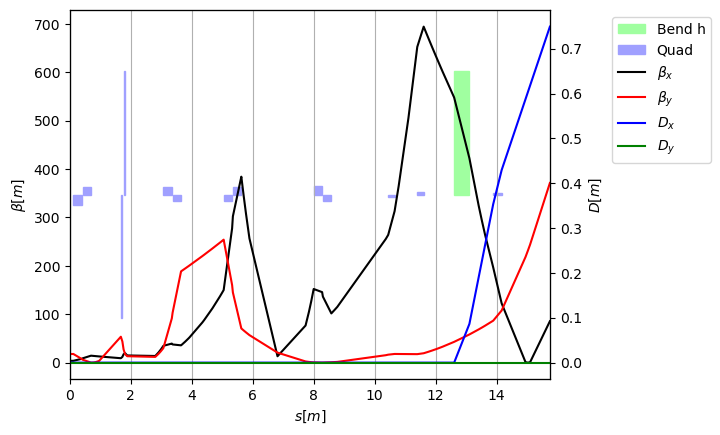

In [2]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEH-DIA-BPM-01",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
p = xsuite_twiss['xtrack_particles']

# s location of IP
ip_idx = (t['name'] == "CLA_FEC1_SIM_FOCUS_01")
scr_idx = (t['name'] == "CLA_FED_DIA_SCR_02")

ip_s = t['s'][ip_idx][0]
scr_s = t['s'][scr_idx][0]

# insert magnets 
hquadf = xtrack.Quadrupole(length=0.05,
                           k1=-119.400000)
hquadd = xtrack.Quadrupole(length=0.05,
                           k1=119.400000)
ip = xtrack.Marker()

l.insert_element(element=hquadf,
                 name="HQUADF",
                 at_s=1.721332 + t['s'][t['name'] == "CLA_FEH_DIA_BPM_01"][0] - 0.05)
l.insert_element(element=hquadd,
                 name="HQUADD",
                 at_s=1.811221 + t['s'][t['name'] == "CLA_FEH_DIA_BPM_01"][0] - 0.05)   
l.insert_element(element=ip,
                 name="ip",
                 at_s=1.811221 + t['s'][t['name'] == "CLA_FEH_DIA_BPM_01"][0])
                 
# get magnet settings from Bruno MAD8
o = pybdsim.External.Pymad8.Output("../PMQ/TWISS_FEBE")

# CLAFEHMAGQUAD01 : 4
# CLAFEHMAGQUAD02 : 7

l.get("CLA_FEH_MAG_QUAD_01").k1 = o.getColumnsByKeys(['K1']).iloc[4]
l.get("CLA_FEH_MAG_QUAD_02").k1 = o.getColumnsByKeys(['K1']).iloc[7]

mad8_twiss0 = xtrack.TwissInit(betx = 3.73528,
                               alfx = -0.404159,
                               dx = 0,
                               dpx = 0,
                               bety = 17.8614,
                               alfy = -0.080607,
                               dy = 0,
                               dpy = 0)

t_pmq = l.twiss(method="4d",init=mad8_twiss0)
t_pmq.plot()

BETX    0.017
dtype: float64


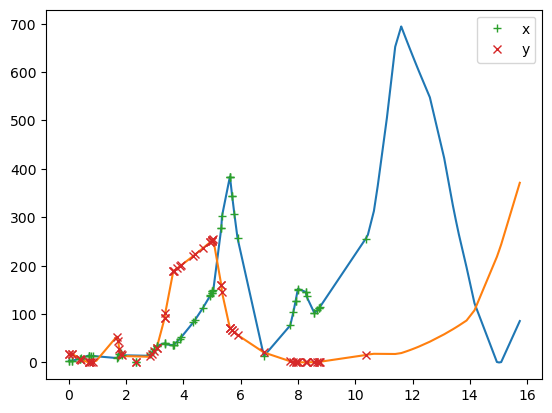

In [87]:
plt.plot(t_pmq['s'],t_pmq['betx'],"-")
plt.plot(t_pmq['s'],t_pmq['bety'],"-")

plt.plot(o.getColumnsByKeys(['S']),o.getColumnsByKeys(['BETX']),"+", label="x")
plt.plot(o.getColumnsByKeys(['S']),o.getColumnsByKeys(['BETY']),"x", label="y")

print(o.getColumnsByKeys(['BETX']).min())

plt.legend()
#plt.xlim(0,6)
#plt.ylim(0,100)

### Tracking through solution

In [2]:
xsuite_twiss = pyclara.Converters.elegant2xsuite("../PostInjector/FEBE.lte",
                                                 line_name="FEBE",
                                                 start_element="CLA-FEA-SIM-DIP-04-END",
                                                 end_element="CLA-FED-SIM-DUMP-01-START",
                                                 elegant_twi="../Run/FEBE.twi")

e = xsuite_twiss['env']
l = xsuite_twiss['env'].lines['FEBE']
t = xsuite_twiss['xtrack_twiss']
t0 = xsuite_twiss['xtrack_twiss0']
t0d = xsuite_twiss['dict_twiss0']
p = xsuite_twiss['xtrack_particles']

xtrack_particles = pyclara.Converters.elegant2xsuite_particles("../Run/CLA-FEA-SIM-DIP-04-END.SDDS",l)
pyclara.Converters.xsuite_Add_ParticlesMonitor(l,len(xtrack_particles.x))
l.track(xtrack_particles)

Slicing line:   0%|          | 0/160 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/161 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/162 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/164 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/166 [00:00<?, ?it/s]

...

Slicing line:   0%|          | 0/491 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/493 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/494 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/496 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/498 [00:00<?, ?it/s]

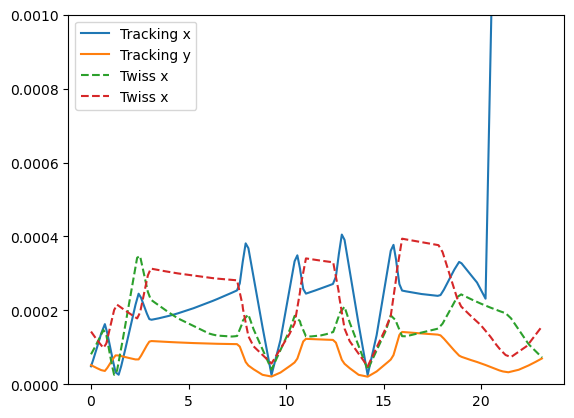

In [9]:
bs = pyclara.Converters.xsuite_CalculateBeamSize(l)

epsilon_n = 3e-6
gamma = 250/0.511
epsilon = epsilon_n/gamma

plt.plot(bs['s'], bs['x_sigma'], "-",label="Tracking x")
plt.plot(bs['s'], bs['y_sigma'], "-",label="Tracking y")
plt.plot(t['s'],np.sqrt(epsilon*t['betx']),"--", label="Twiss x")
plt.plot(t['s'],np.sqrt(epsilon*t['bety']),"--", label="Twiss x")
plt.ylim(0,0.001)
plt.legend()